In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import glob
import sys
from itertools import groupby
from operator import itemgetter
import matplotlib.colors as colors
import seaborn as sns

In [2]:
files = glob.glob("../hdf5_files/*")

In [11]:
files

['../hdf5_files/event_211274458.h5',
 '../hdf5_files/event_256893462.h5',
 '../hdf5_files/event_216741224.h5',
 '../hdf5_files/event_236442324.h5',
 '../hdf5_files/event_242764060.h5',
 '../hdf5_files/event_212636270.h5',
 '../hdf5_files/event_219288990.h5',
 '../hdf5_files/event_239076863.h5',
 '../hdf5_files/event_222684112.h5',
 '../hdf5_files/event_221627323.h5',
 '../hdf5_files/event_98790022.h5',
 '../hdf5_files/event_109687805.h5',
 '../hdf5_files/event_126350302.h5',
 '../hdf5_files/event_222848068.h5',
 '../hdf5_files/event_258517814.h5',
 '../hdf5_files/event_239712228.h5',
 '../hdf5_files/event_211047255.h5',
 '../hdf5_files/event_95818679.h5',
 '../hdf5_files/event_259787063.h5',
 '../hdf5_files/event_131043138.h5',
 '../hdf5_files/event_259870951.h5',
 '../hdf5_files/event_93970574.h5']

In [12]:
cov_fn = glob.glob("results/Covs/*")

In [13]:
cov_fn

['results/Covs/event_222684112_100',
 'results/Covs/event_239076863_100',
 'results/Covs/event_259787063_100',
 'results/Covs/event_131043138_100',
 'results/Covs/event_216741224_100',
 'results/Covs/event_98790022_100',
 'results/Covs/event_258517814_100',
 'results/Covs/event_221627323_100',
 'results/Covs/event_256893462_100',
 'results/Covs/event_259870951_100',
 'results/Covs/event_126350302_100',
 'results/Covs/event_219288990_100',
 'results/Covs/event_236442324_100',
 'results/Covs/event_93970574_100',
 'results/Covs/event_95818679_100',
 'results/Covs/event_239712228_100',
 'results/Covs/event_212636270_100',
 'results/Covs/event_109687805_100',
 'results/Covs/event_211047255_100',
 'results/Covs/event_211274458_100',
 'results/Covs/event_222848068_100']

In [14]:
import re

In [15]:
# Helper function to extract numerical ID
def get_id(filepath):
    match = re.search(r'event_(\d+)', filepath)
    return match.group(1) if match else None

# Map IDs to their paths
dict1 = {get_id(f): f for f in files if get_id(f)}
dict2 = {get_id(f): f for f in cov_fn if get_id(f)}

# Find overlapping IDs sorted numerically
matching_ids = sorted(list(set(dict1.keys()) & set(dict2.keys())), key=int)

# Re-align paths based on matching IDs
sorted_fn= [dict1[eid] for eid in matching_ids]
sorted_cov= [dict2[eid] for eid in matching_ids]

In [16]:
sorted_fn

['../hdf5_files/event_93970574.h5',
 '../hdf5_files/event_95818679.h5',
 '../hdf5_files/event_98790022.h5',
 '../hdf5_files/event_109687805.h5',
 '../hdf5_files/event_126350302.h5',
 '../hdf5_files/event_131043138.h5',
 '../hdf5_files/event_211047255.h5',
 '../hdf5_files/event_211274458.h5',
 '../hdf5_files/event_212636270.h5',
 '../hdf5_files/event_216741224.h5',
 '../hdf5_files/event_219288990.h5',
 '../hdf5_files/event_221627323.h5',
 '../hdf5_files/event_222684112.h5',
 '../hdf5_files/event_222848068.h5',
 '../hdf5_files/event_236442324.h5',
 '../hdf5_files/event_239076863.h5',
 '../hdf5_files/event_239712228.h5',
 '../hdf5_files/event_256893462.h5',
 '../hdf5_files/event_258517814.h5',
 '../hdf5_files/event_259787063.h5',
 '../hdf5_files/event_259870951.h5']

In [17]:
sorted_cov

['results/Covs/event_93970574_100',
 'results/Covs/event_95818679_100',
 'results/Covs/event_98790022_100',
 'results/Covs/event_109687805_100',
 'results/Covs/event_126350302_100',
 'results/Covs/event_131043138_100',
 'results/Covs/event_211047255_100',
 'results/Covs/event_211274458_100',
 'results/Covs/event_212636270_100',
 'results/Covs/event_216741224_100',
 'results/Covs/event_219288990_100',
 'results/Covs/event_221627323_100',
 'results/Covs/event_222684112_100',
 'results/Covs/event_222848068_100',
 'results/Covs/event_236442324_100',
 'results/Covs/event_239076863_100',
 'results/Covs/event_239712228_100',
 'results/Covs/event_256893462_100',
 'results/Covs/event_258517814_100',
 'results/Covs/event_259787063_100',
 'results/Covs/event_259870951_100']

In [18]:
covs = np.empty((len(sorted_cov), 100, 100))
for i in range(len(sorted_cov)):
    cov = np.load(sorted_cov[i]+"/Cov.npy")
    covs[i] = cov

In [19]:
times = []
for fn in sorted_fn:
    times.append(h5py.File(fn).attrs["unix_timestamp"])

In [20]:
times

[np.int64(1356274574),
 np.int64(1358122679),
 np.int64(1361094022),
 np.int64(1371991805),
 np.int64(1388654302),
 np.int64(1393347138),
 np.int64(1473351255),
 np.int64(1473578458),
 np.int64(1474940270),
 np.int64(1479045224),
 np.int64(1481592990),
 np.int64(1483931323),
 np.int64(1484988112),
 np.int64(1485152068),
 np.int64(1498746324),
 np.int64(1501380863),
 np.int64(1502016228),
 np.int64(1519197462),
 np.int64(1520821814),
 np.int64(1522091063),
 np.int64(1522174951)]

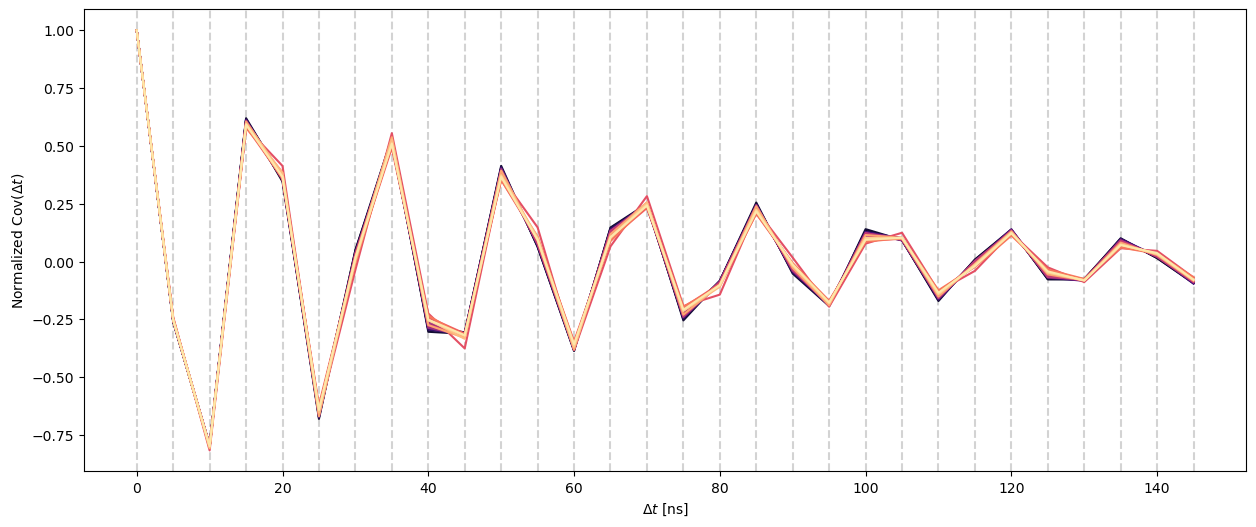

In [22]:
ent = 30
cmap = plt.cm.magma
totn = len(covs)

x = np.arange(ent)*5

plt.figure(figsize=(15,6))
for i in range(ent):
    plt.axvline(i*5, c="lightgray", linestyle="--")

for i in range(len(covs)):
    color = cmap(i/totn)
    plt.plot(x, covs[i, 0, :ent]/covs[i, 0, 0], c=color)

plt.xlabel(r"$\Delta t$ [ns]")
plt.ylabel(r"Normalized Cov($\Delta t$)")

plt.show()

In [23]:
from datetime import datetime, timezone

In [24]:
r_times = []
for time in times:
    r_times.append(datetime.fromtimestamp(time, tz=timezone.utc))

In [25]:
r_times

[datetime.datetime(2012, 12, 23, 14, 56, 14, tzinfo=datetime.timezone.utc),
 datetime.datetime(2013, 1, 14, 0, 17, 59, tzinfo=datetime.timezone.utc),
 datetime.datetime(2013, 2, 17, 9, 40, 22, tzinfo=datetime.timezone.utc),
 datetime.datetime(2013, 6, 23, 12, 50, 5, tzinfo=datetime.timezone.utc),
 datetime.datetime(2014, 1, 2, 9, 18, 22, tzinfo=datetime.timezone.utc),
 datetime.datetime(2014, 2, 25, 16, 52, 18, tzinfo=datetime.timezone.utc),
 datetime.datetime(2016, 9, 8, 16, 14, 15, tzinfo=datetime.timezone.utc),
 datetime.datetime(2016, 9, 11, 7, 20, 58, tzinfo=datetime.timezone.utc),
 datetime.datetime(2016, 9, 27, 1, 37, 50, tzinfo=datetime.timezone.utc),
 datetime.datetime(2016, 11, 13, 13, 53, 44, tzinfo=datetime.timezone.utc),
 datetime.datetime(2016, 12, 13, 1, 36, 30, tzinfo=datetime.timezone.utc),
 datetime.datetime(2017, 1, 9, 3, 8, 43, tzinfo=datetime.timezone.utc),
 datetime.datetime(2017, 1, 21, 8, 41, 52, tzinfo=datetime.timezone.utc),
 datetime.datetime(2017, 1, 23, 6, 

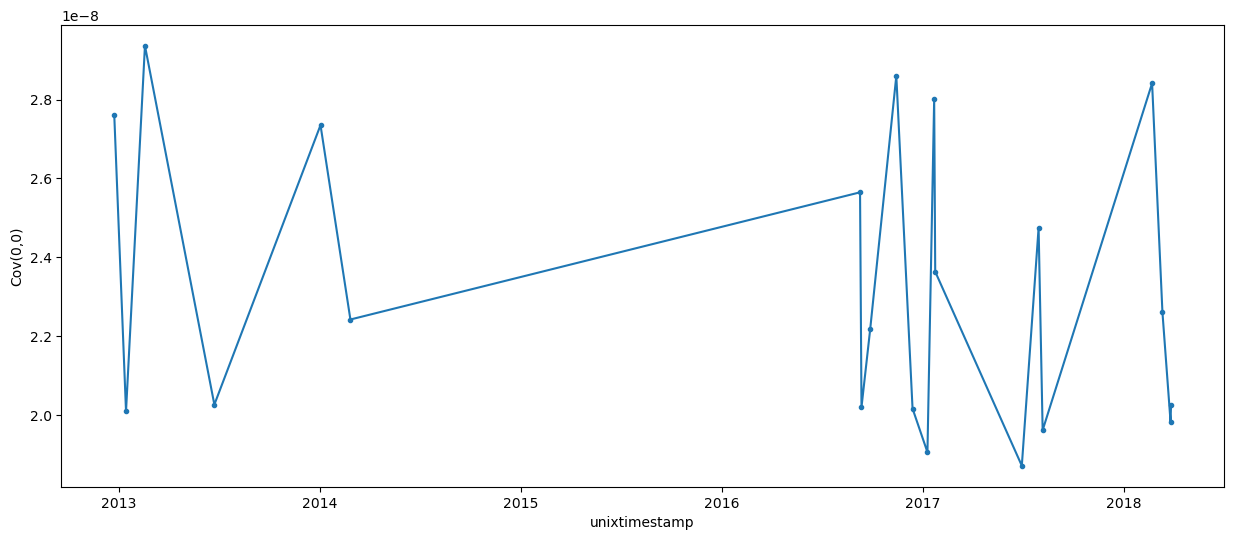

In [26]:
plt.figure(figsize=(15,6))
plt.plot(r_times, covs[:,0,0])
plt.scatter(r_times, covs[:,0,0], marker=".")
plt.xlabel("unixtimestamp")
plt.ylabel("Cov(0,0)")
plt.show()

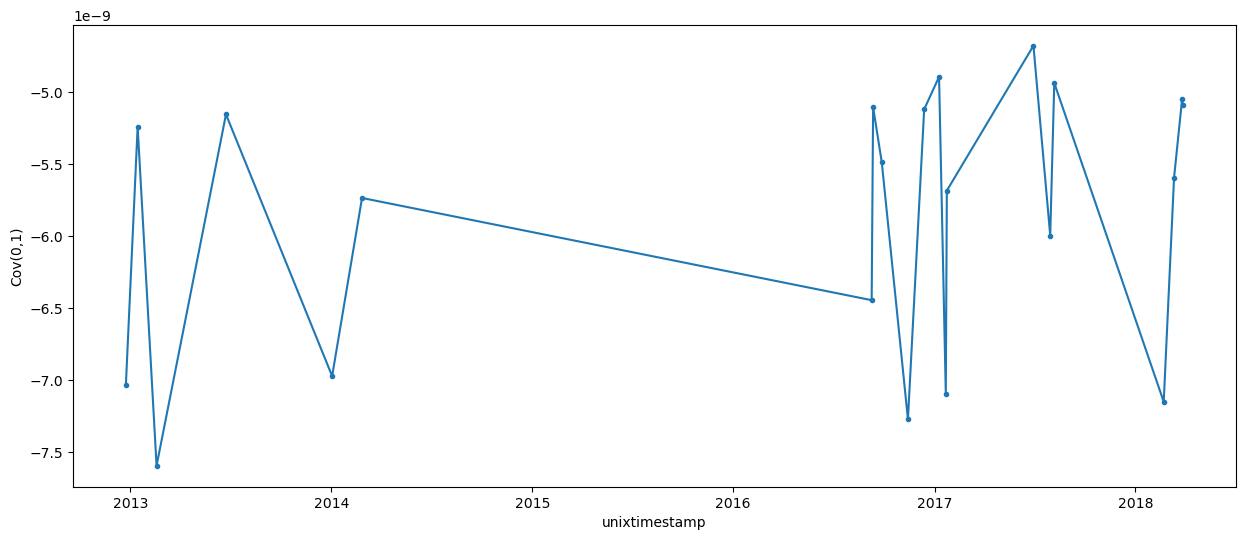

In [27]:
plt.figure(figsize=(15,6))
plt.plot(r_times, covs[:,0,1])
plt.scatter(r_times, covs[:,0,1], marker=".")
plt.xlabel("unixtimestamp")
plt.ylabel("Cov(0,1)")
plt.show()

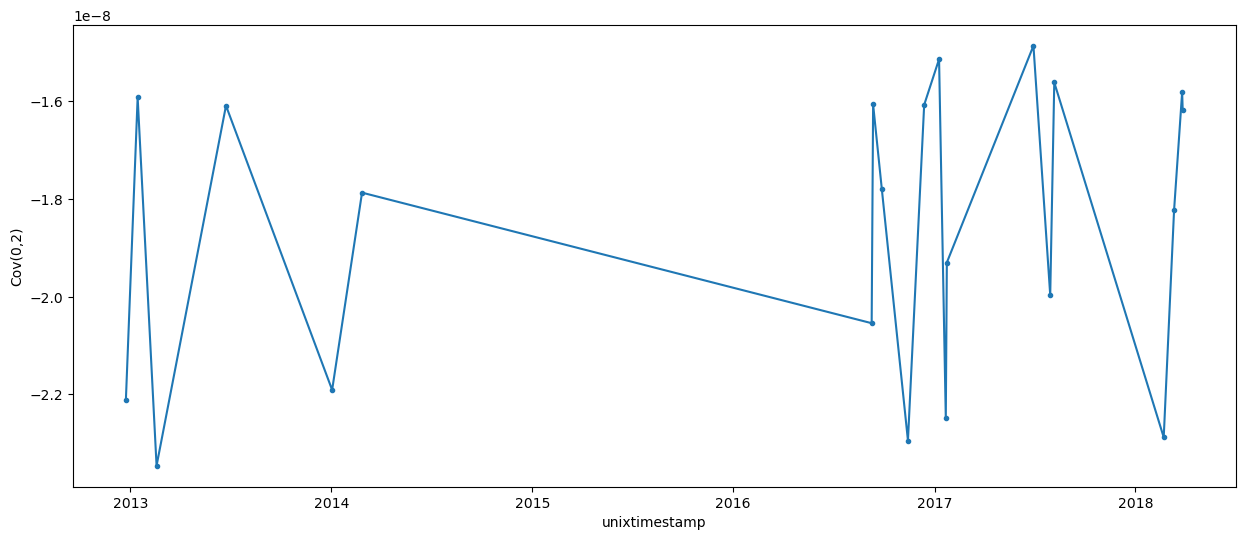

In [28]:
plt.figure(figsize=(15,6))
plt.plot(r_times, covs[:,0,2])
plt.scatter(r_times, covs[:,0,2], marker=".")
plt.xlabel("unixtimestamp")
plt.ylabel("Cov(0,2)")
plt.show()

In [29]:
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

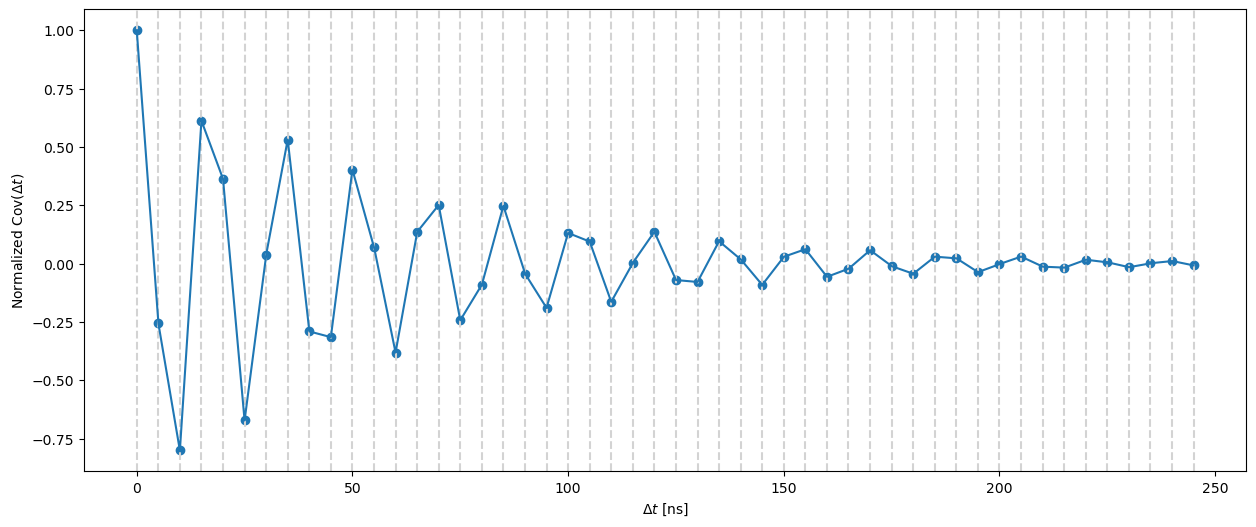

In [30]:
ent = 50
x = np.arange(ent)*5
f = interp1d(x, covs[0,0,:ent]/covs[0,0,0])

x_smooth = np.arange(0, x[-1], 0.01)

plt.figure(figsize=(15,6))
for i in range(ent):
    plt.axvline(i*5, c="lightgray", linestyle="--")

plt.plot(x_smooth, f(x_smooth))
plt.scatter(x, covs[0,0,:ent]/covs[0,0,0])

plt.xlabel(r"$\Delta t$ [ns]")
plt.ylabel(r"Normalized Cov($\Delta t$)")

plt.show()

In [52]:
def try_fit(func, ent, space, leg, title, covs):
    x = np.arange(ent)*5
    f = interp1d(x, covs[0,0,:ent]/covs[0,0,0])

    x_smooth = np.arange(0, x[-1], space)

    cmap = plt.cm.magma
    totn = len(covs)

    popt, pcov = curve_fit(func, x_smooth, f(x_smooth))
    print(popt)

    string_fn = np.vectorize(lambda x: f"{x:.2f}")
    string_popt = ", ".join(string_fn(popt))

    plt.figure(figsize=(15,6))
    for i in range(ent):
        plt.axvline(i*5, c="lightgray", linestyle="--")

    for i in range(len(covs)):
        color = cmap(i/totn)
        plt.plot(x, covs[i, 0, :ent]/covs[i, 0, 0], c=color)

    plt.plot(x_smooth, func(x_smooth, *popt), label=f"scipy optimized fit\n"+rf"({leg}) = ({string_popt})")
    # plt.plot(x_smooth, cos_func(x_smooth, 1, 30, 17.5, 0), color="red")

    plt.xlabel(r"$\Delta t$ [ns]")
    plt.ylabel(r"Normalized Cov($\Delta t$)")
    plt.title(rf"{title}")
    plt.legend()

    plt.show()

### damped cosine

In [53]:
def cos_func(x, tau, T, phi):
    return np.exp(-x/tau)*np.cos(2*np.pi*x/T+phi)
    

/tmp/ipykernel_13988/1988897509.py:2: RuntimeWarning: overflow encountered in exp
  return np.exp(-x/tau)*np.cos(2*np.pi*x/T+phi)


[4.56954169e+01 1.70880222e+01 1.52052346e-02]


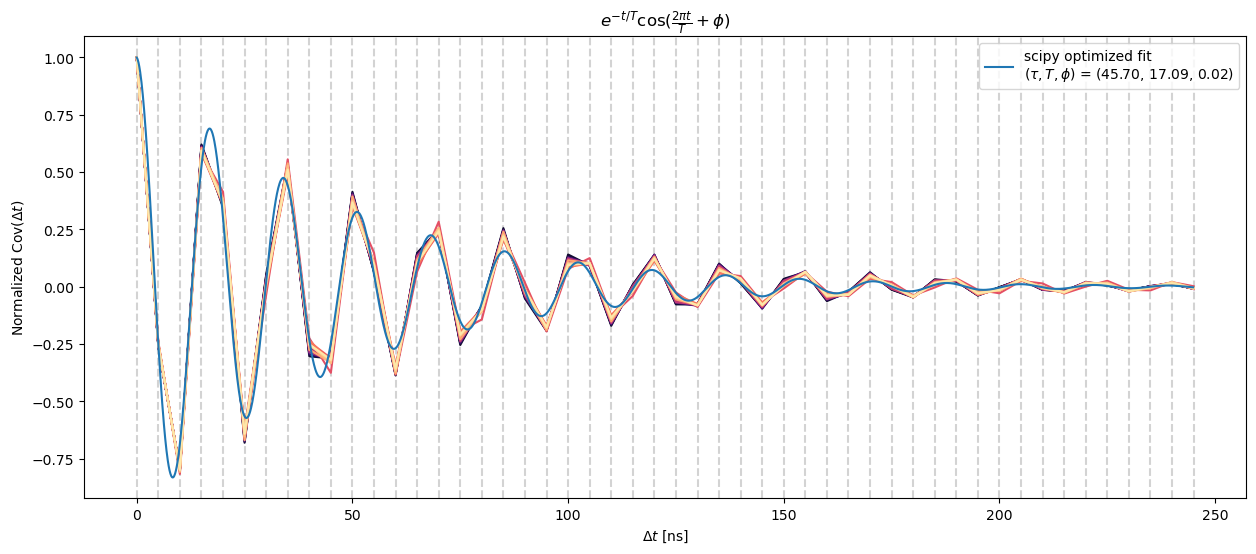

In [55]:
try_fit(cos_func, 50, 0.1, r"$\tau, T, \phi$", r"$e^{-t/T} \cos(\frac{2 \pi t}{T} + \phi)$", covs)

In [ ]:
def cos_func(x, tau, T, phi):
    return np.exp(-x/tau)*np.cos(2*np.pi*x/T+phi)

### Harmonic

In [59]:
def harm_func(x, A, tau, A1, A2, A3, T):
    return np.exp(-x/tau)*(A1*np.cos(2*np.pi*x/T)+A2*np.cos(4*np.pi*x/T)+A3*np.cos(6*np.pi*x/T))

/tmp/ipykernel_13988/389475676.py:2: RuntimeWarning: overflow encountered in exp
  return np.exp(-x/tau)*(A1*np.cos(2*np.pi*x/T)+A2*np.cos(4*np.pi*x/T)+A3*np.cos(6*np.pi*x/T))
/tmp/ipykernel_13988/4255437849.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, x_smooth, f(x_smooth))


[1.00000000e+00 5.82654956e+01 7.97031858e-01 2.16512053e-03
 1.34827812e-03 1.70687531e+01]


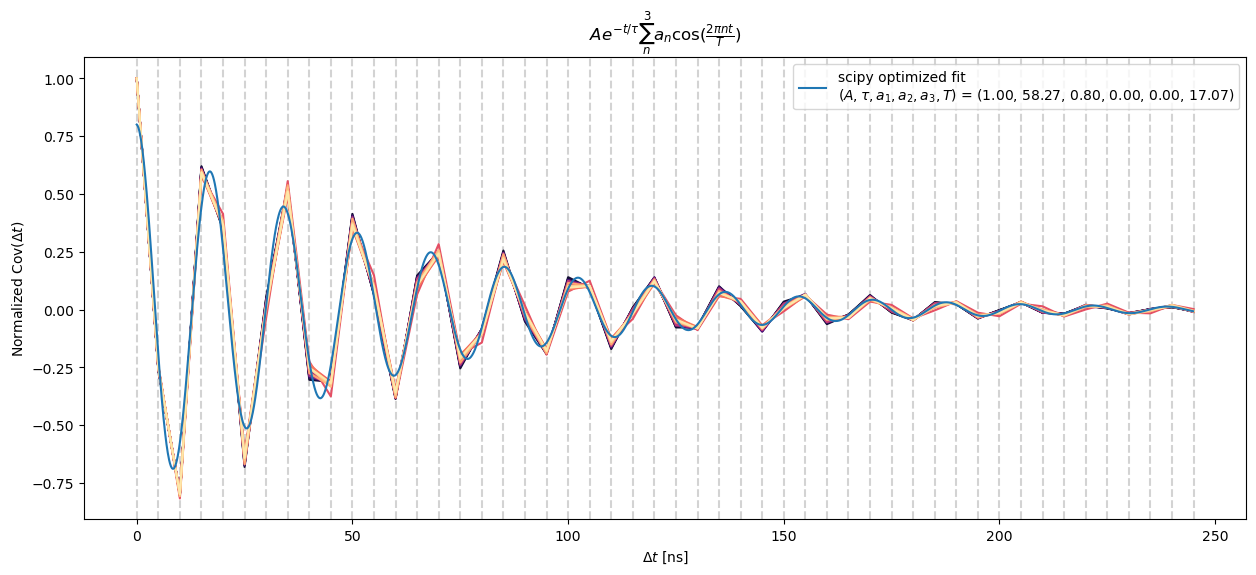

In [60]:
try_fit(harm_func, 50, 0.1, r"$A, \tau, a_1, a_2, a_3, T$", r"$Ae^{-t/\tau} \sum_n^3 a_n \cos (\frac{2 \pi nt}{T})$", covs)

### Damped sinc

In [63]:
def damped_sinc_func(x, A, tau, omega):
    return A*np.exp(-x/tau)*np.sinc(omega*x)

[7.27231470e-01 4.43921345e+09 1.39059104e-01]


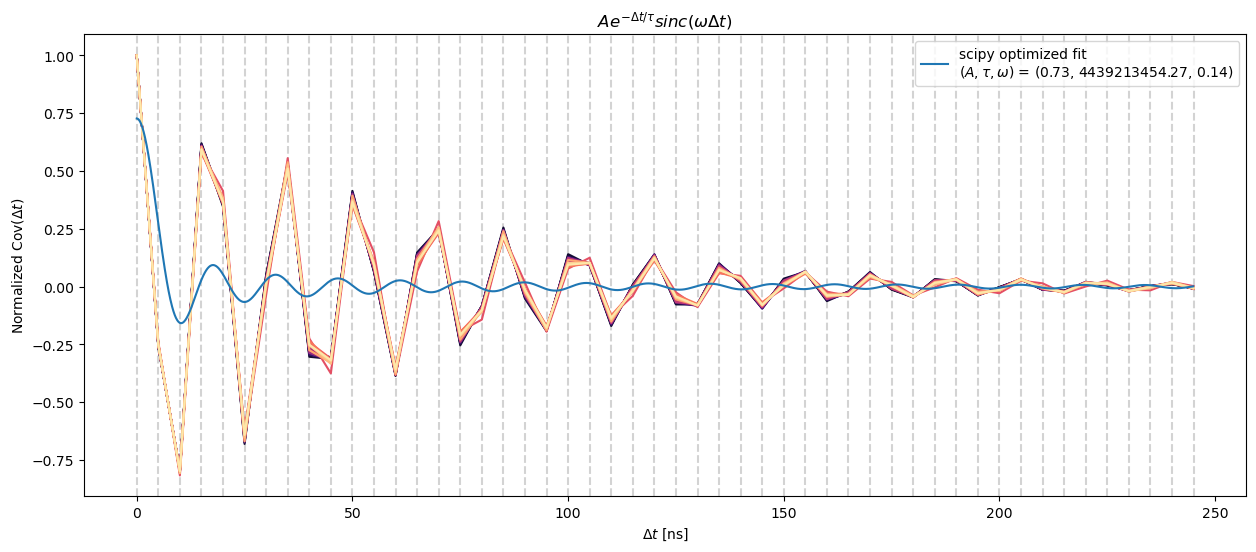

In [64]:
try_fit(damped_sinc_func, 50, 0.1, r"$A, \tau, \omega$", r"$A e^{- \Delta t/\tau} sinc (\omega \Delta t)$", covs)

### sinc function

In [65]:
def sinc_func(x, A, omega):
    return A*np.sinc(omega*x)

[0.95088124 0.92160107]


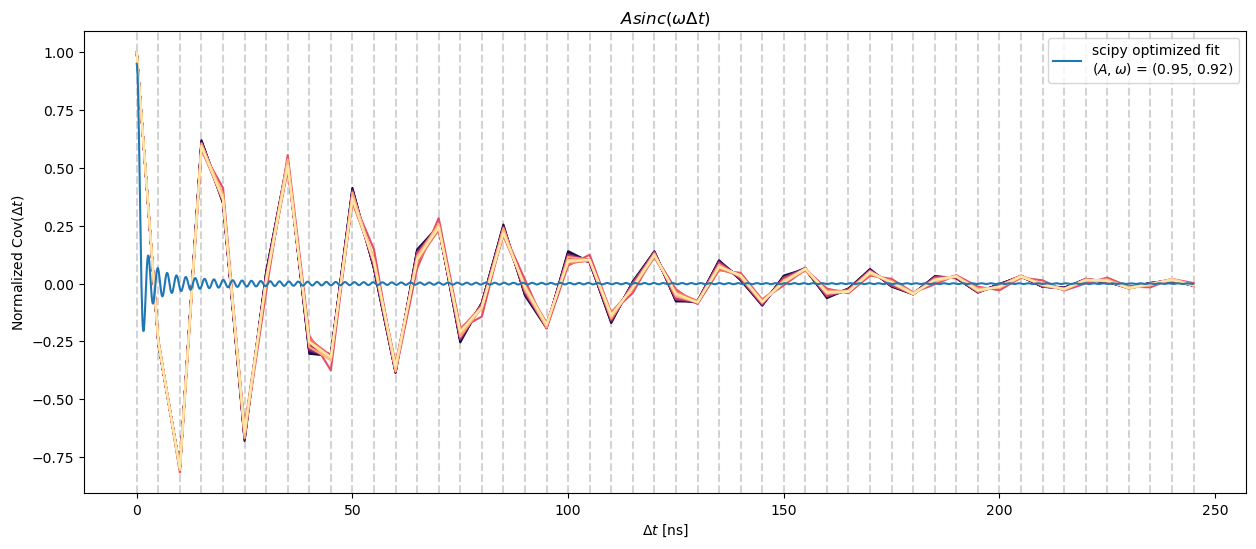

In [67]:
try_fit(sinc_func, 50, 0.1, r"$A, \omega$", r"$A sinc (\omega \Delta t)$", covs)

### Bessel Function

In [61]:
from scipy.special import jv

In [62]:
def Bessel_func(x, A, tau, k):
    return A*np.exp(-x/tau)*jv(0,k*x)